In [28]:
from const import *
import pandas as pd
import numpy as np
import scipy
import random

from itertools import product

from matplotlib import pyplot as plt

from sklearn.decomposition import PCA

# Data processing

In [2]:
df = pd.read_csv("./data/games.csv")

df = df.loc[df.bugged==False].loc[df.has_abandon==False].reset_index()

In [3]:
def get_idx_from_ids(tmp_ab):
    ab_list = tmp_ab.flatten()
    ab_id2idx = {}
    ab_list_mapped = np.zeros(ab_list.shape[0],dtype=np.int)

    for i, j in enumerate(ab_list):
        if ab_id2idx.get(j) is None:
            ab_id2idx[j] = len(ab_id2idx)
        ab_list_mapped[i] = ab_id2idx[j]

    X_ab = ab_list_mapped.reshape(tmp_ab.shape)
    return X_ab, ab_id2idx

In [4]:
tmp_hero = df[[f"hero{i}" for i in range(10)]].to_numpy()
tmp_ab = df[[f"ab{i}{j}" for i, j in product(range(10), range(4))]].to_numpy()

X_ab, ab_id2idx = get_idx_from_ids(tmp_ab)
X_hero, hero_id2idx = get_idx_from_ids(tmp_hero)

Y = df["radiant_win"].to_numpy()

In [5]:
X_ab.shape, X_hero.shape, Y.shape

((309923, 40), (309923, 10), (309923,))

In [6]:
def to_multi_hot(X):
    n = X.max()+1
    mat = np.zeros((X.shape[0], n), dtype=np.int8)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            if X[i,j] != 0:
                mat[i, X[i, j]] += 1
    return mat

In [7]:
X_ab_rad = X_ab[:,:20]
X_ab_dire = X_ab[:,20:]
X_hero_rad = X_hero[:,:5]
X_hero_dire = X_hero[:,5:]

X_rad_mh = np.concatenate([to_multi_hot(X_ab_rad), to_multi_hot(X_hero_rad)], axis=1)
X_dire_mh = np.concatenate([to_multi_hot(X_ab_dire), to_multi_hot(X_hero_dire)], axis=1)

# Logistic regression

In [8]:
random.seed(1111)

r = 0.7
train_mask = np.random.binomial(1, r, X_rad_mh.shape[0]).astype(np.bool)
test_mask = np.logical_not(train_mask)

X_train = X_rad_mh[train_mask,:] - X_dire_mh[train_mask,:]
Y_train = Y[train_mask]

X_test = X_rad_mh[test_mask,:] - X_dire_mh[test_mask,:]
Y_test = Y[test_mask]

In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(penalty='none', max_iter=1000)
model.fit(X_train, Y_train)

LogisticRegression(max_iter=1000, penalty='none')

In [10]:
model.score(X_train, Y_train)

0.6834014408663647

In [11]:
model.score(X_test, Y_test)

0.681008280617341

# LinearSVM

In [8]:
random.seed(1111)

r = 0.5
train_mask = np.random.binomial(1, r, X_rad_mh.shape[0]).astype(np.bool)
test_mask = np.logical_not(train_mask)

X_train = X_rad_mh[train_mask,:] - X_dire_mh[train_mask,:]
Y_train = Y[train_mask]

X_test = X_rad_mh[test_mask,:] - X_dire_mh[test_mask,:]
Y_test = Y[test_mask]

In [9]:
from sklearn.svm import LinearSVC

In [16]:
model = LinearSVC(C=1e3, max_iter=10000)
model.fit(X_train, Y_train)

D:\dev\anaconda3\lib\site-packages\sklearn\svm\_base.py:1206: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(C=1000.0, max_iter=10000)

In [17]:
model.score(X_train, Y_train)

0.5779104785611566

In [18]:
model.score(X_test, Y_test)

0.5757035659395301

# AdaBoost

In [31]:
random.seed(1111)

r = 0.1
train_mask = np.random.binomial(1, r, X_rad_mh.shape[0]).astype(np.bool)
test_mask = np.logical_not(train_mask)

X_tmp = X_rad_mh - X_dire_mh

X_train = X_tmp[train_mask, :]
Y_train = Y[train_mask]

X_test = X_tmp[test_mask, :]
Y_test = Y[test_mask]

In [21]:
from sklearn.ensemble import AdaBoostClassifier

In [26]:
model = AdaBoostClassifier(n_estimators=100, random_state=0)
model.fit(X_train, Y_train)

AdaBoostClassifier(n_estimators=100, random_state=0)

In [27]:
model.score(X_train, Y_train)

0.6339814305587008

In [ ]:
model.score(X_test, Y_test)

In [32]:
pca = PCA()
pca.fit(X_tmp)

PCA()

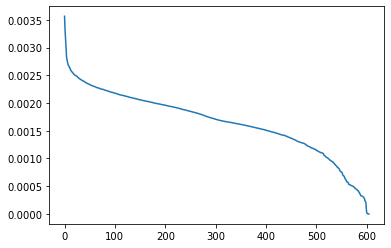

In [33]:
plt.plot(pca.explained_variance_ratio_)